# DATE3 实验3：Naive Prefetch的及时性—干扰权衡

本实验对应论文C3，只比较`Static-NoPF`和`Static-NaivePF`，用于刻画传统预取的局限，
不在本实验中提前报告最终MemDomain性能。数据来自32组Window×Chunk配置。


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

roots=[Path.cwd().resolve(),Path.cwd().resolve().parent]
ROOT=next(p for p in roots if (p/'outputs/DATE3/exp3/naive_prefetch_interference.csv').exists())
DATA=ROOT/'outputs/DATE3/exp3/naive_prefetch_interference.csv'
FIG=ROOT/'fig/DATE3';FIG.mkdir(parents=True,exist_ok=True)
d=pd.read_csv(DATA)
required={'window','chunk_tiles','baseline','total_cycles','prefetch_requests',
          'prefetch_bytes','bank_conflict_count','bank_conflict_rate',
          'prefetch_interference_stall_cycles','timely_prefetch_ratio',
          'late_prefetch_ratio','unused_prefetch_ratio',
          'prefetch_occupancy_byte_cycles','compute_transfer_overlap_cycles',
          'coverage','accuracy','prefetched_unique_bytes',
          'coverage_valid','accuracy_valid'}
assert required.issubset(d.columns)
assert len(d)==64
assert set(d.baseline)=={'Static-NoPF','Static-NaivePF'}
assert d.groupby(['window','chunk_tiles']).size().eq(2).all()
assert sorted(d.window.unique())==[0,1,2,4,8,16,32,64]
assert sorted(d.chunk_tiles.unique())==[1,2,4,8]
pf=d[d.baseline.eq('Static-NaivePF')].merge(
    d[d.baseline.eq('Static-NoPF')],on=['window','chunk_tiles'],
    suffixes=('_pf','_nop'),validate='one_to_one')
pf['cycle_change_pct']=(pf.total_cycles_pf/pf.total_cycles_nop-1)*100
conflict_den=pf.bank_conflict_count_nop.to_numpy()
conflict_num=(pf.bank_conflict_count_pf-pf.bank_conflict_count_nop).to_numpy()
pf['conflict_change_pct']=np.where(conflict_den>0,conflict_num/conflict_den*100,
                                         np.where(conflict_num==0,0.0,np.nan))
pf['interference_stall_delta']=(
    pf.prefetch_interference_stall_cycles_pf-pf.prefetch_interference_stall_cycles_nop)
pf['occupancy_mbyte_cycles']=pf.prefetch_occupancy_byte_cycles_pf/1e6
print('Validated 32 Window×Chunk pairs')


Validated 32 Window×Chunk pairs


## 1. 性能结果：预取可以加速，也可以显著减速


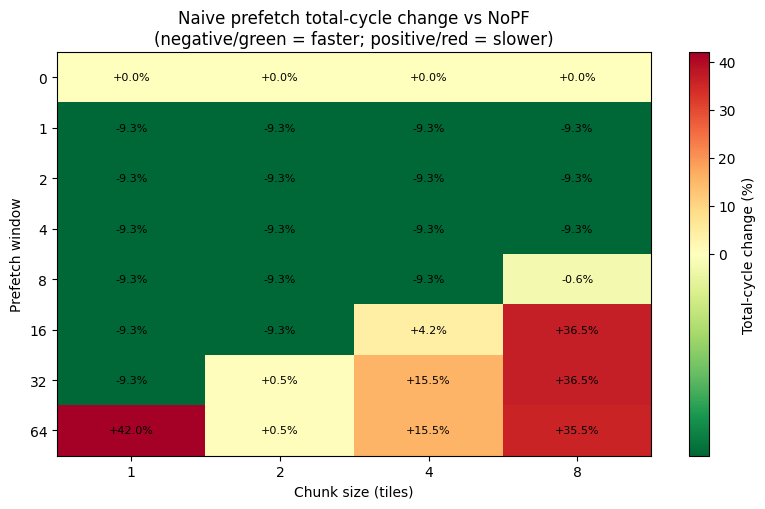

Faster configurations: 19 / 28
Slower configurations: 9 / 28
Best change: -9.29%
Worst change: +42.00%


In [2]:
perf=pf.pivot(index='window',columns='chunk_tiles',values='cycle_change_pct')
fig,ax=plt.subplots(figsize=(8.2,5.2))
vmin=float(np.nanmin(perf.to_numpy())); vmax=float(np.nanmax(perf.to_numpy()))
im=ax.imshow(perf,aspect='auto',cmap='RdYlGn_r',
             norm=TwoSlopeNorm(vmin=vmin,vcenter=0,vmax=vmax))
ax.set_xticks(range(len(perf.columns)),perf.columns)
ax.set_yticks(range(len(perf.index)),perf.index)
ax.set_xlabel('Chunk size (tiles)');ax.set_ylabel('Prefetch window')
ax.set_title('Naive prefetch total-cycle change vs NoPF\n(negative/green = faster; positive/red = slower)')
for i in range(len(perf.index)):
    for j in range(len(perf.columns)):
        ax.text(j,i,f'{perf.iloc[i,j]:+.1f}%',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='Total-cycle change (%)')
plt.tight_layout();plt.savefig(FIG/'exp3_performance_heatmap.pdf',bbox_inches='tight');plt.show()
active=pf[pf.window.gt(0)]
print('Faster configurations:',int(active.cycle_change_pct.lt(0).sum()),'/',len(active))
print('Slower configurations:',int(active.cycle_change_pct.gt(0).sum()),'/',len(active))
print(f'Best change: {active.cycle_change_pct.min():+.2f}%')
print(f'Worst change: {active.cycle_change_pct.max():+.2f}%')


## 2. 不匹配的 Window×Chunk：迟到与驻留压力增加


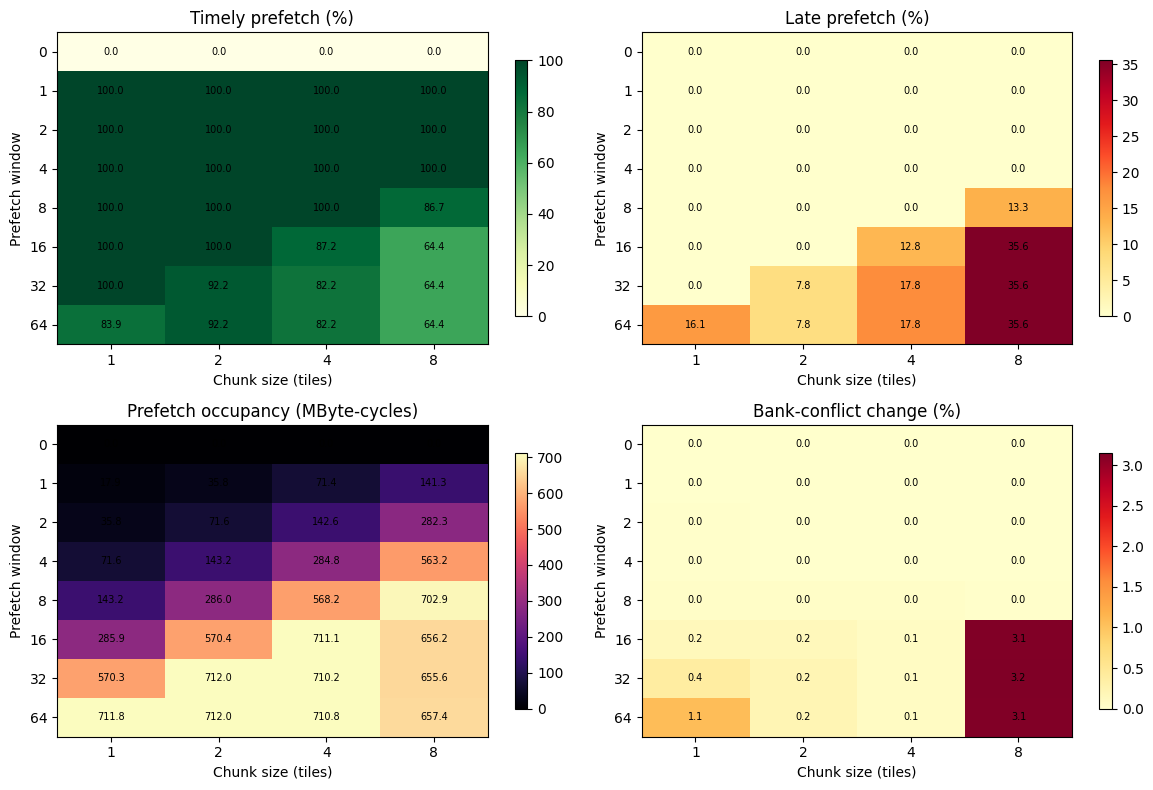

In [3]:
metrics=[
 ('timely_prefetch_ratio_pf','Timely prefetch (%)','YlGn',100),
 ('late_prefetch_ratio_pf','Late prefetch (%)','YlOrRd',100),
 ('occupancy_mbyte_cycles','Prefetch occupancy (MByte-cycles)','magma',1),
 ('conflict_change_pct','Bank-conflict change (%)','YlOrRd',1)]
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,(col,title,cmap,scale) in zip(axes.ravel(),metrics):
    p=pf.pivot(index='window',columns='chunk_tiles',values=col)*scale
    im=ax.imshow(p,aspect='auto',cmap=cmap)
    ax.set_xticks(range(len(p.columns)),p.columns);ax.set_yticks(range(len(p.index)),p.index)
    ax.set_xlabel('Chunk size (tiles)');ax.set_ylabel('Prefetch window');ax.set_title(title)
    for i in range(len(p.index)):
        for j in range(len(p.columns)):
            ax.text(j,i,f'{p.iloc[i,j]:.1f}',ha='center',va='center',fontsize=7)
    fig.colorbar(im,ax=ax,shrink=.82)
plt.tight_layout();plt.savefig(FIG/'exp3_timeliness_occupancy_conflict.pdf',bbox_inches='tight');plt.show()


## 3. 性能退化的原因与相关性


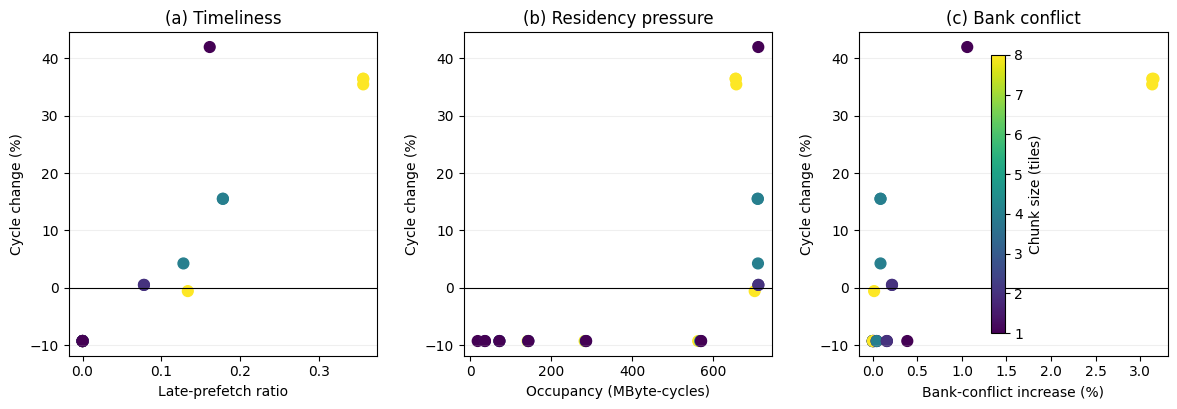

,cycle_change_pct,timely_prefetch_ratio_pf,late_prefetch_ratio_pf,occupancy_mbyte_cycles,conflict_change_pct
cycle_change_pct,1.000,-0.934,0.934,0.630,0.833
timely_prefetch_ratio_pf,-0.934,1.000,-1.000,-0.645,-0.883
late_prefetch_ratio_pf,0.934,-1.000,1.000,0.645,0.883
occupancy_mbyte_cycles,0.630,-0.645,0.645,1.000,0.415
conflict_change_pct,0.833,-0.883,0.883,0.415,1.000


In [4]:
q=pf[pf.window.gt(0)].copy()
fig,axes=plt.subplots(1,3,figsize=(14,4.2))
scatter = None
for ax,x,label,title in [
    (axes[0],'late_prefetch_ratio_pf','Late-prefetch ratio','(a) Timeliness'),
    (axes[1],'occupancy_mbyte_cycles','Occupancy (MByte-cycles)','(b) Residency pressure'),
    (axes[2],'conflict_change_pct','Bank-conflict increase (%)','(c) Bank conflict')]:
    scatter=ax.scatter(q[x],q.cycle_change_pct,c=q.chunk_tiles,cmap='viridis',s=60)
    ax.axhline(0,color='black',lw=.8);ax.set_xlabel(label);ax.set_ylabel('Cycle change (%)')
    ax.set_title(title);ax.grid(axis='y',alpha=.2)
colorbar=fig.colorbar(scatter,ax=axes.ravel().tolist(),shrink=.86,pad=.02)
colorbar.set_label('Chunk size (tiles)')
cor=q[['cycle_change_pct','timely_prefetch_ratio_pf','late_prefetch_ratio_pf',
       'occupancy_mbyte_cycles','conflict_change_pct']].corr()
fig.subplots_adjust(wspace=.28,right=.91)
plt.savefig(FIG/'exp3_root_cause_correlation.pdf',bbox_inches='tight');plt.show()
display(cor.round(3))


## 3.1 退化周期的直接分量归因

下图只展示发生退化的配置，并使用原始 baseline matrix 的周期分量差值。
正值表示预取增加了该路径的暴露周期，负值表示预取消除了部分等待。


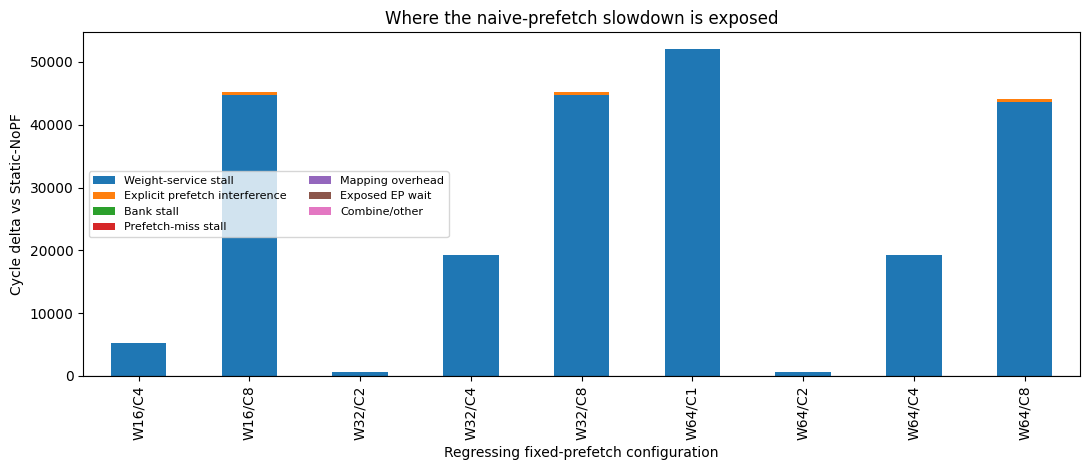

,window,chunk_tiles,total_cycle_delta,weight_load_stall_cycles,prefetch_interference_stall_cycles,bank_stall_cycles,prefetch_miss_stall_cycles,mapping_overhead_cycles,communication_stall_cycles,other_stall_cycles
22,16,4,5268,5268,0,0,0,0,0,0
23,16,8,45230,44750,480,0,0,0,0,0
25,32,2,624,624,0,0,0,0,0,0
26,32,4,19260,19260,0,0,0,0,0,0
27,32,8,45230,44750,480,0,0,0,0,0
28,64,1,52098,52098,0,0,0,0,0,0
29,64,2,624,624,0,0,0,0,0,0
30,64,4,19260,19260,0,0,0,0,0,0
31,64,8,44014,43534,480,0,0,0,0,0


In [5]:
component_fields = [
    'bank_stall_cycles', 'weight_load_stall_cycles',
    'prefetch_miss_stall_cycles', 'prefetch_interference_stall_cycles',
    'mapping_overhead_cycles', 'communication_stall_cycles',
    'other_stall_cycles',
]
component_rows = []
for window in sorted(pf.window.unique()):
    for chunk in sorted(pf.chunk_tiles.unique()):
        source = ROOT / 'outputs/DATE3/window_chunk' / f'w{window}_c{chunk}' / 'baseline_matrix.csv'
        matrix = pd.read_csv(source).set_index('baseline')
        static = matrix.loc['Static-NoPF']
        naive = matrix.loc['Static-NaivePF']
        row = {'window': window, 'chunk_tiles': chunk}
        for field in component_fields:
            row[field] = naive[field] - static[field]
        row['component_delta_sum'] = sum(row[field] for field in component_fields)
        row['total_cycle_delta'] = naive.total_cycles - static.total_cycles
        component_rows.append(row)
components = pd.DataFrame(component_rows)
assert np.allclose(components.component_delta_sum, components.total_cycle_delta)
regressing = components[components.total_cycle_delta.gt(0)].copy()
regressing['config'] = 'W' + regressing.window.astype(str) + '/C' + regressing.chunk_tiles.astype(str)
plot_columns = [
    'weight_load_stall_cycles', 'prefetch_interference_stall_cycles',
    'bank_stall_cycles', 'prefetch_miss_stall_cycles', 'mapping_overhead_cycles',
    'communication_stall_cycles', 'other_stall_cycles',
]
component_labels = {
    'weight_load_stall_cycles': 'Weight-service stall',
    'prefetch_interference_stall_cycles': 'Explicit prefetch interference',
    'bank_stall_cycles': 'Bank stall',
    'prefetch_miss_stall_cycles': 'Prefetch-miss stall',
    'mapping_overhead_cycles': 'Mapping overhead',
    'communication_stall_cycles': 'Exposed EP wait',
    'other_stall_cycles': 'Combine/other',
}
fig, ax = plt.subplots(figsize=(11, 4.8))
regressing.set_index('config')[plot_columns].rename(columns=component_labels).plot(
    kind='bar', stacked=True, ax=ax
)
ax.axhline(0, color='black', lw=.8)
ax.set_ylabel('Cycle delta vs Static-NoPF')
ax.set_xlabel('Regressing fixed-prefetch configuration')
ax.set_title('Where the naive-prefetch slowdown is exposed')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'exp3_component_attribution.pdf', bbox_inches='tight'); plt.show()
display(regressing[['window', 'chunk_tiles', 'total_cycle_delta', *plot_columns]])


## 4. 所有预取最终都被使用，仍可能伤害性能


In [6]:
used_but_slower=pf[(pf.window.gt(0))&(pf.unused_prefetch_ratio_pf.eq(0))&
                   (pf.cycle_change_pct.gt(0))].copy()
cols=['window','chunk_tiles','cycle_change_pct','timely_prefetch_ratio_pf',
      'late_prefetch_ratio_pf','occupancy_mbyte_cycles','conflict_change_pct']
display(used_but_slower[cols].sort_values('cycle_change_pct',ascending=False))
print('Unused-prefetch ratio range:',
      pf[pf.window.gt(0)].unused_prefetch_ratio_pf.min(),
      pf[pf.window.gt(0)].unused_prefetch_ratio_pf.max())
print('Used-but-slower configurations:',len(used_but_slower))
assert len(used_but_slower)>0


,window,chunk_tiles,cycle_change_pct,timely_prefetch_ratio_pf,late_prefetch_ratio_pf,occupancy_mbyte_cycles,conflict_change_pct
28,64,1,41.996905,0.838889,0.161111,711.843840,1.059565
27,32,8,36.460517,0.644444,0.355556,655.601664,3.150057
23,16,8,36.460517,0.644444,0.355556,656.240640,3.135739
31,64,8,35.480282,0.644444,0.355556,657.389568,3.135739
30,64,4,15.525747,0.822222,0.177778,710.806528,0.085911
26,32,4,15.525747,0.822222,0.177778,710.161408,0.085911
22,16,4,4.246606,0.872222,0.127778,711.060480,0.085911
25,32,2,0.503015,0.922222,0.077778,711.966720,0.214777
29,64,2,0.503015,0.922222,0.077778,711.966720,0.214777


Unused-prefetch ratio range: 0.0 0.0
Used-but-slower configurations: 9


## 5. 逐项论文契约检查


In [7]:
small_windows=pf[pf.window.isin([1,2])]
large_windows=pf[pf.window.isin([32,64])]
verdict={
 'Naive prefetch can improve performance':bool((q.cycle_change_pct<0).any()),
 'Naive prefetch can degrade performance':bool((q.cycle_change_pct>0).any()),
 'Large Window increases occupancy':bool(
     large_windows.occupancy_mbyte_cycles.mean()>small_windows.occupancy_mbyte_cycles.mean()),
 'Large Window/Chunk can become late':bool(
     pf[(pf.window>=16)&(pf.chunk_tiles>=4)].late_prefetch_ratio_pf.max()>0),
 'Used data can still interfere':bool(len(used_but_slower)>0),
 'Small Window is measurably late':bool(small_windows.late_prefetch_ratio_pf.max()>0),
 'Explicit interference-stall attribution changes':bool(
     pf.interference_stall_delta.abs().max()>0),
 'Small-Chunk control overhead is modeled':False,
}
display(pd.Series(verdict,name='supported by current data'))
assert all(verdict[k] for k in [
 'Naive prefetch can improve performance','Naive prefetch can degrade performance',
 'Large Window increases occupancy','Large Window/Chunk can become late',
 'Used data can still interfere'])


Naive prefetch can improve performance              True
Naive prefetch can degrade performance              True
Large Window increases occupancy                    True
Large Window/Chunk can become late                  True
Used data can still interfere                       True
Small Window is measurably late                    False
Explicit interference-stall attribution changes     True
Small-Chunk control overhead is modeled            False
Name: supported by current data, dtype: bool

In [8]:
active = pf[pf.window.gt(0)].copy()
best = active.loc[active.cycle_change_pct.idxmin()]
worst = active.loc[active.cycle_change_pct.idxmax()]
short = active[active.window.isin([1, 2, 4])]
large = active[active.window.isin([16, 32, 64])]
quality_identity = np.allclose(
    active.coverage_pf, active.accuracy_pf, equal_nan=True
)
same_volume = active.prefetched_unique_bytes_pf.nunique() == 1
explicit_interference_count = int(
    active.interference_stall_delta.ne(0).sum()
)
metrics = pd.Series({
    'active_configurations': len(active),
    'faster_configurations': int(active.cycle_change_pct.lt(0).sum()),
    'slower_configurations': int(active.cycle_change_pct.gt(0).sum()),
    'best_cycle_change_pct': best.cycle_change_pct,
    'best_window': int(best.window),
    'best_chunk': int(best.chunk_tiles),
    'worst_cycle_change_pct': worst.cycle_change_pct,
    'worst_window': int(worst.window),
    'worst_chunk': int(worst.chunk_tiles),
    'late_ratio_correlation': active[['cycle_change_pct', 'late_prefetch_ratio_pf']].corr().iloc[0, 1],
    'occupancy_correlation': active[['cycle_change_pct', 'occupancy_mbyte_cycles']].corr().iloc[0, 1],
    'conflict_correlation': active[['cycle_change_pct', 'conflict_change_pct']].corr().iloc[0, 1],
    'explicit_interference_nonzero_configs': explicit_interference_count,
    'all_active_configs_prefetch_same_bytes': same_volume,
    'coverage_equals_accuracy_here': quality_identity,
})
display(metrics.rename('value').to_frame().round(4))
checks = pd.Series({
    'Both speedup and slowdown are observed': active.cycle_change_pct.lt(0).any() and active.cycle_change_pct.gt(0).any(),
    'Large fixed settings can become late': large.late_prefetch_ratio_pf.gt(0).any(),
    'Late ratio tracks slowdown': metrics['late_ratio_correlation'] > 0.8,
    'Occupancy tracks slowdown': metrics['occupancy_correlation'] > 0.5,
    'Some slowdown has explicit interference': explicit_interference_count > 0,
    'All prefetched data can still be harmful': ((active.unused_prefetch_ratio_pf == 0) & (active.cycle_change_pct > 0)).any(),
})
display(checks.rename('pass').to_frame())
assert checks.all(), checks[~checks]


,value
active_configurations,28
faster_configurations,19
slower_configurations,9
best_cycle_change_pct,-9.286428
best_window,1
best_chunk,1
worst_cycle_change_pct,41.996905
worst_window,64
worst_chunk,1
late_ratio_correlation,0.933536


,pass
Both speedup and slowdown are observed,True
Large fixed settings can become late,True
Late ratio tracks slowdown,True
Occupancy tracks slowdown,True
Some slowdown has explicit interference,True
All prefetched data can still be harmful,True


## DATE3 实验 3 论文判断

- **核心 C3 结论以本次输出为准**：只有上一单元同时报告至少一个加速点和至少一个减速点，才能写成“固定 Naive Prefetch 不是单调有益”。配置数量、最佳/最差点和百分比必须引用上方动态生成的 `metrics`，不能沿用旧结果。
- **退化链条必须由分量图支撑**：结合 late ratio、驻留 byte-cycles、Bank conflict 和显式 interference 分量说明原因；不把相关性写成因果，也不预设一定是大 Window 或大 Chunk 最差。
- **不能写成简单单调规律**：结果不是“Window/Chunk 越大一定越差”。不同组合表现明显非单调，恰恰说明 Window、Chunk 和 Bank placement 必须联合在线选择。
- **覆盖边界由布尔检查决定**：不能预先声称某个 Window 区间全部及时，也不能预先声称 Coverage 与 Accuracy 相等；分别读取 `checks`、`same_volume` 和 `quality_identity`。
- **控制开销边界**：若 `mapping_overhead_cycles` 始终为零，本实验不能证明小 Chunk 的控制开销，只能讨论传输及时性、驻留和 Bank 干扰。

因此 Exp3 足以完成论文中的过渡论证：**只采用固定预取会出现性能和资源占用风险，需要后续的 Bank-aware、Coverage/Accuracy-constrained Chunk/Window 协同优化。**
